# 2. Most In-Demand Genres for Movies vs. TV Shows

**Question:** What are the most common genres for Movies and for TV Shows in Netflix's catalog?

This mirrors asking "what skills are most in demand for the top roles" — here, the two "roles" are the two content types Netflix offers, and the "skills" are genres.

## Import & Clean Up Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('netflix_titles.csv')

# A title can belong to multiple genres (e.g. "Dramas, International Movies")
# so we explode listed_in into one row per (title, genre) pair before counting.
df['genre_list'] = df['listed_in'].str.split(', ')
df_genres = df.explode('genre_list').rename(columns={'genre_list': 'genre'})

df_genres[['title', 'type', 'genre']].head()

## Visualize Data

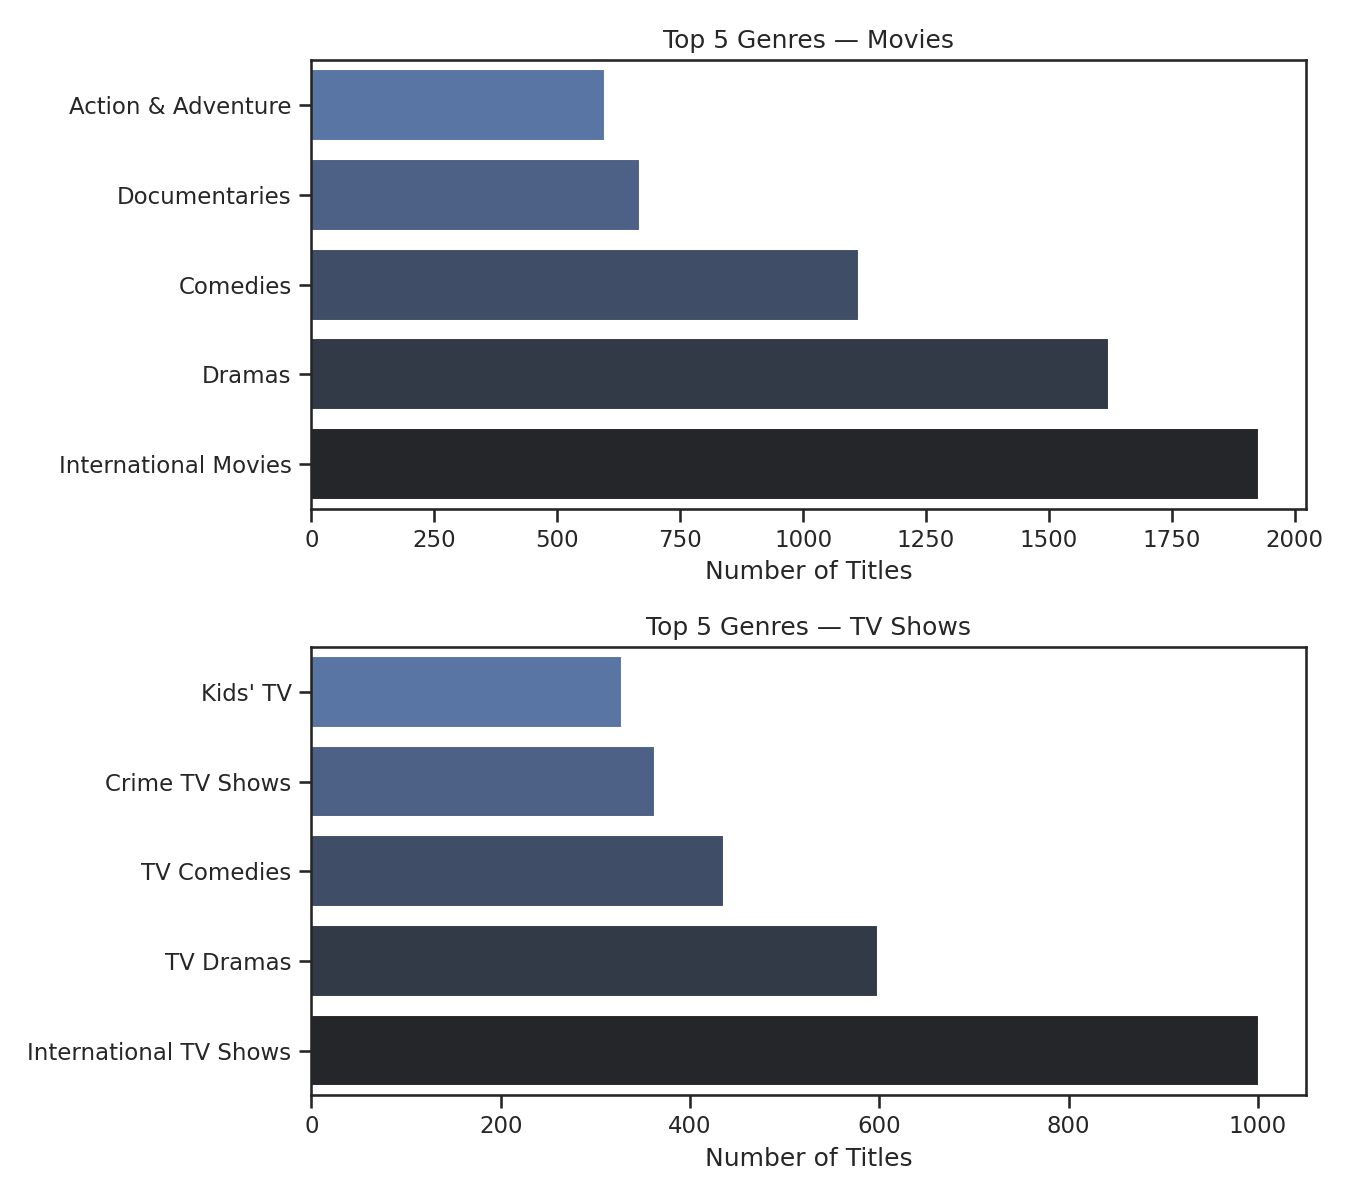

In [1]:
fig, ax = plt.subplots(2, 1, figsize=(9, 8))

for i, t in enumerate(['Movie', 'TV Show']):
    top5 = df_genres[df_genres['type'] == t]['genre'].value_counts().head(5).sort_values()
    sns.barplot(x=top5.values, y=top5.index, ax=ax[i], hue=top5.index, palette='dark:b_r', legend=False)
    ax[i].set_title(f'Top 5 Genres — {t}s')
    ax[i].set_xlabel('Number of Titles')
    ax[i].set_ylabel('')

plt.tight_layout()
plt.show()

### Insights

- **International Movies** (1,927 titles) and **Dramas** (1,623) are the two largest genres in the Movie catalog by a wide margin, together making up nearly 40% of all movies.
- On the TV Show side, **International TV Shows** (1,001) leads, followed by **TV Dramas** (599) and **TV Comedies** (436) — a similar international/drama-heavy pattern to the movie catalog.
- **Documentaries** and **Action & Adventure** round out the movie top 5, showing Netflix balances broad entertainment genres with a meaningful documentary presence.